In [16]:
import xgboost as xgb
from pandas import read_csv
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [10]:
df = read_csv('./agg.csv')
x_cols = ['Ta', 'Rh', 'R', 'CO2']
y_col = 'Tl'

df.head()

,Unnamed: 0,DateTime_start,Ta,Rh,R,CO2,Tl
0,0,2021-03-09T00:08:30.0,22.536364,80.363636,0.0,416.272727,25.836832
1,1,2021-03-09T00:18:30.0,22.600000,79.563636,0.0,416.909091,26.256781
2,2,2021-03-09T00:28:30.0,22.618182,80.581818,0.0,415.818182,25.955940
3,3,2021-03-09T00:38:30.0,22.700000,79.018182,0.0,416.090909,25.710634
4,4,2021-03-09T00:48:30.0,22.663636,79.954545,0.0,415.909091,25.644834


In [11]:
X = df[x_cols]
y = df[y_col]

# 시계열 데이터이므로 순서를 유지하며 Train/Test 분할
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [18]:
# XGBoost 모델 생성 및 학습
model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    n_jobs=-1,
    early_stopping_rounds=50,
    verbosity=1
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [19]:
y_pred = model_xgb.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred):.4f}")

R2 Score: 0.8890
RMSE: 5.5355


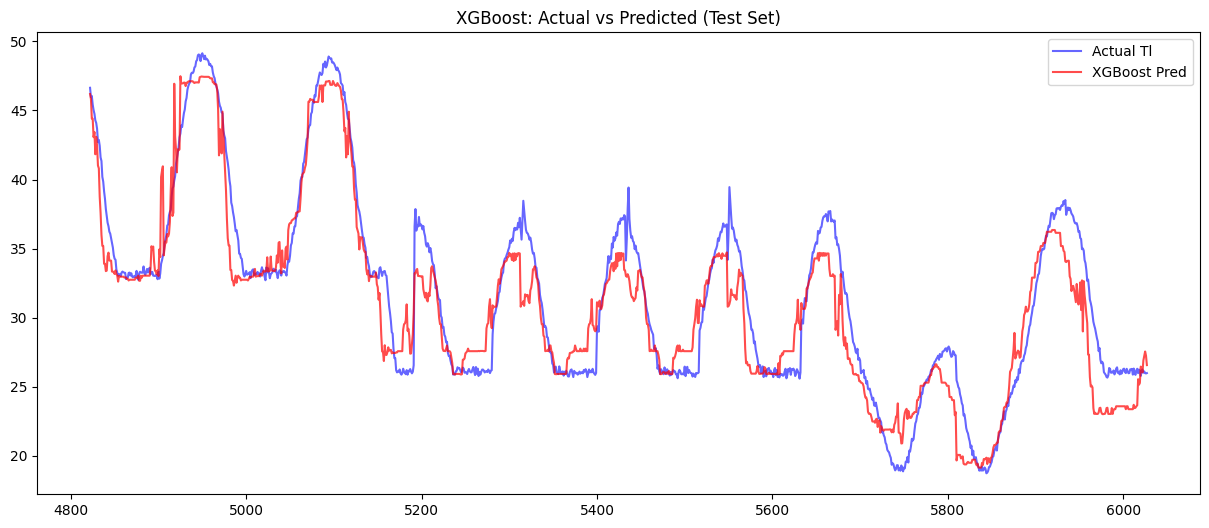

In [20]:
#일단 StandarScaling을 통해서 0과 가까운 값으로 통일을 하지 않았음에도 불구하고 이정도면 그렇게 나쁘지는 않다고 보임.
#그냥 XGBoost만 쓴게 이정도니까 일단 더 분석을 해보고 finetuning을 이것 저것 해보면 될 것 같다.
#재미있게도 시계열 데이터의 특성을 오히려 반영하지 않은, Seasonality를 고려하지 않은게 더 성능이 좋다는것.
#아마 Seanonality가 실제로 아래에도 그렇게 보이지 않는다는 것을 감안하면 사실 그렇게 문제가 되는 것은 아닌 것 같다.

plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test.values, label='Actual Tl', alpha=0.6, color='blue')
plt.plot(y_test.index, y_pred, label='XGBoost Pred', alpha=0.7, color='red')
plt.title('XGBoost: Actual vs Predicted (Test Set)')
plt.legend()
plt.show()